In [7]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from data_tools import process_data as processed
from data_tools.combine_data import CreateTrainingandTestData
from data_tools import process_dates
from data_tools import handle_datetime
from data_tools import clean_data as clean

combine = CreateTrainingandTestData()
# Change as needed
sensor_id = "Coalinguita"
datatype = "o3"
year = "2025"
calibration = "Pre"

training_dates = process_dates.training(sensor_id, year, calibration)
testing_dates= process_dates.testing(sensor_id, year, calibration)

# Define files that hold necessary raw data
reference_file_1 = rf"../reference_files/OZONE_PICKDATA_2025-7-29-Fresno.csv"
reference_file_2 = rf"../reference_files/AQLite-2025-11-06.csv"
sensor_file = rf"../reference_files/2025rawdata/{sensor_id}.csv"
precal_reference = handle_datetime.utc_to_CA(processed.ref_data(reference_file_1))
postcal_reference = processed.standard_data(reference_file_2)
postcal_reference = postcal_reference.resample('h').mean()
postcal_reference.index = postcal_reference.index.map(lambda ts: ts.replace(minute=30, second=0, microsecond=0))
postcal_reference = handle_datetime.utc_to_CA(postcal_reference)
voz_data = handle_datetime.utc_to_CA(processed.raw_voz_data(sensor_file))

when = {
    "precal_start": training_dates[0],
    "precal_end": training_dates[1],
    "postcal_start": training_dates[2],
    "postcal_end": training_dates[3],
    "trial1_start": testing_dates[0],
    "trial1_end": testing_dates[1],
    "trial2_start": testing_dates[2],
    "trial2_end": testing_dates[3]
}

combine.set_calibration_parameters(datatype,sensor_id,voz_data)
training_data,all_data = combine.get_combined_data(training_dates,testing_dates,precal_reference,postcal_reference)
training_data, all_data = map(lambda df: clean.eliminate_waste_data_o3(df), [training_data, all_data])

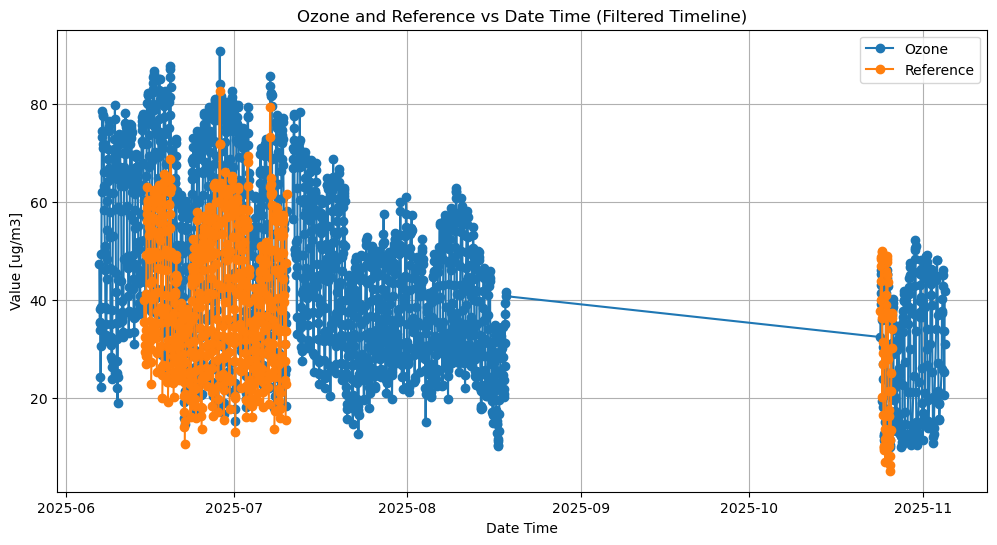

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the start and end dates for the desired timeline
start_date_filter = pd.to_datetime(f"{year}-06-07")
end_date_filter = pd.to_datetime(f"{year}-11-21")

# Apply the date range filter to the merged data
filtered_data = all_data[(all_data.index >= start_date_filter) & (all_data.index <= end_date_filter)]

# Line plot for 'o3' and 'reference' columns against 'date_time' within the specified timeline
plt.figure(figsize=(12, 6))

# Plot 'o3' column
plt.plot(filtered_data.index, filtered_data["o3"], label='Ozone', marker='o')

# Plot 'reference' column
plt.plot(filtered_data.index, filtered_data['reference'], label='Reference', marker='o')

# Customize the plot
plt.title('Ozone and Reference vs Date Time (Filtered Timeline)')
plt.xlabel('Date Time')
plt.ylabel('Value [ug/m3]')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
from data_tools import elastic_net
#elasticnet regression with x variables

variables = ["o3","temp_C","rh","m_PM25_CF1","week"]
output = rf"../reference_files/2025rawdata/ozone_calibration_variables/{sensor_id}_coefficients.csv"
new_column = "o3_calibrated"

all_data = all_data.dropna(subset=variables)
training_data = training_data.dropna(subset=variables + ['reference'])

print(all_data)
try:
    calibration_model = elastic_net.calibrate(training_data, variables, output)
    calibrated_data = elastic_net.apply_calibration(calibration_model,all_data,variables,new_column)
    print("Calibrated data:", calibrated_data[new_column])
except ValueError as e:
    print("Error:", e)



                       unixtime     temp_C         rh         o3  m_PM25_CF1  \
date_time                                                                      
2025-06-02 16:30:00  1748908800  35.000000  17.000000  81.444000    3.000000   
2025-06-02 17:30:00  1748910900  34.500000  16.833333  81.296000    3.000000   
2025-06-02 18:30:00  1748914500  33.333333  19.333333  81.213000    3.166667   
2025-06-02 19:30:00  1748918100  31.333333  21.500000  80.585500    3.500000   
2025-06-02 20:30:00  1748921700  29.500000  24.666667  75.093333    3.833333   
...                         ...        ...        ...        ...         ...   
2025-11-04 18:30:00  1762309501  18.166667  38.000000  33.667833    3.666667   
2025-11-04 19:30:00  1762313101  15.666667  44.833333  25.414333    3.000000   
2025-11-04 20:30:00  1762316701  15.000000  46.833333  20.681000    4.500000   
2025-11-04 21:30:00  1762320301  16.333333  46.666667  31.101500    5.500000   
2025-11-04 22:30:00  1762323301  18.0000

In [10]:
calibrated_file = rf"../reference_files/{year}OzoneDataCalibrated/{sensor_id}_calibrated{calibration}.csv"
calibrated_data.to_csv(calibrated_file, index=True)

                       unixtime     temp_C         rh         o3  m_PM25_CF1  \
date_time                                                                      
2025-06-15 00:30:00  1749972301  23.500000  36.500000  57.589667    3.166667   
2025-06-15 01:30:00  1749975901  22.000000  38.333333  52.256167    3.666667   
2025-06-15 02:30:00  1749979501  20.666667  39.666667  47.963167    3.500000   
2025-06-15 03:30:00  1749983101  18.833333  44.166667  43.687833    4.000000   
2025-06-15 04:30:00  1749986701  18.666667  43.500000  45.124167    4.500000   
...                         ...        ...        ...        ...         ...   
2025-07-05 00:30:00  1751700900  21.666667  39.333333  40.817833   13.166667   
2025-07-05 01:30:00  1751704500  20.333333  42.333333  40.819333    6.166667   
2025-07-05 02:30:00  1751708100  19.500000  43.333333  38.616833    7.333333   
2025-07-05 03:30:00  1751711700  18.166667  45.500000  37.812833    5.833333   
2025-07-05 04:30:00  1751715300  17.0000

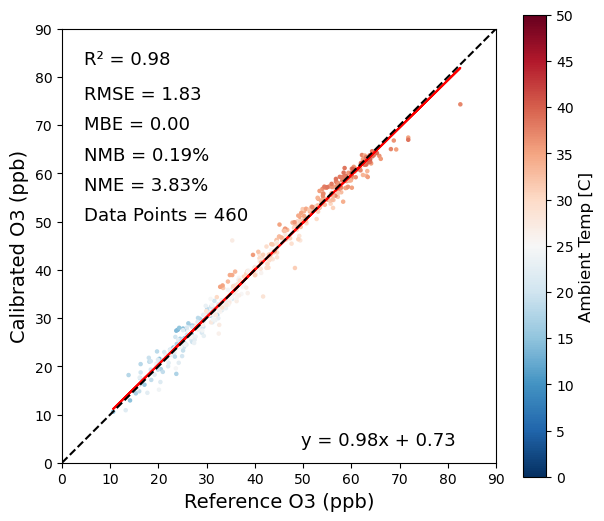

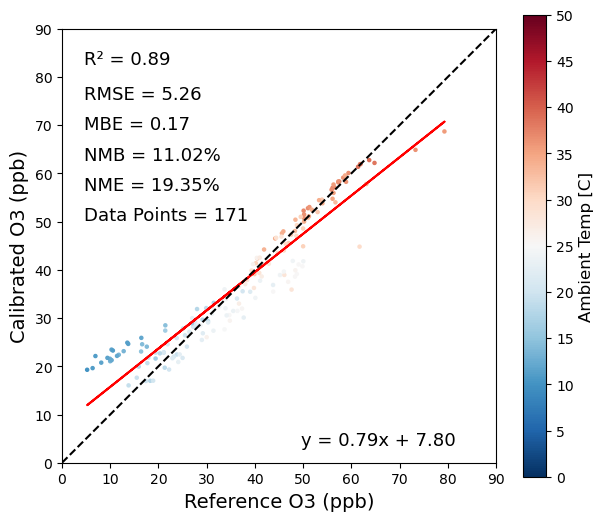

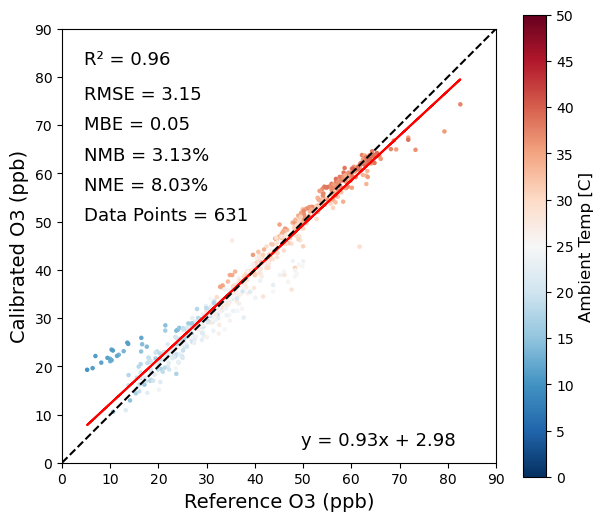

In [11]:
from data_tools.plot_against_reference import PlotOzone
po = PlotOzone()

calibrated_data = calibrated_data.dropna(subset=['reference'])

training_data = combine.subsection(calibrated_data,training_dates)

print(training_data)
testing_data = combine.subsection(calibrated_data,testing_dates)
print(testing_data)
po.plot(training_data,sensor_id,"Training",calibration)
po.plot(testing_data,sensor_id,"Testing",calibration)
po.plot(calibrated_data,sensor_id,"All",calibration)

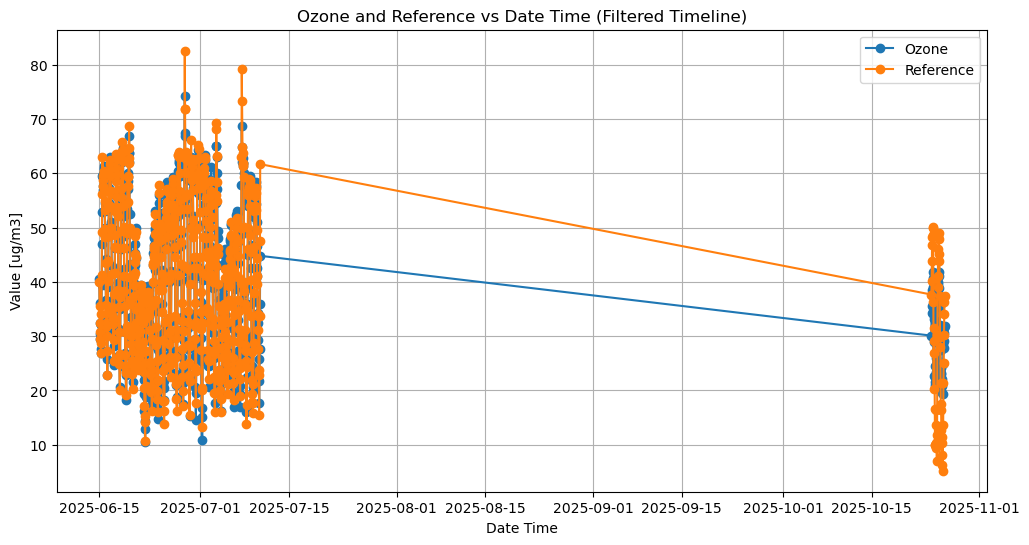

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the start and end dates for the desired timeline
start_date_filter = pd.to_datetime(f"{year}-06-07")
end_date_filter = pd.to_datetime(f"{year}-11-21")

# Apply the date range filter to the merged data
filtered_data = calibrated_data[(calibrated_data.index >= start_date_filter) & (calibrated_data.index <= end_date_filter)]

# Line plot for 'o3' and 'reference' columns against 'date_time' within the specified timeline
plt.figure(figsize=(12, 6))

# Plot 'o3' column
plt.plot(filtered_data.index, filtered_data["o3_calibrated"], label='Ozone', marker='o')

# Plot 'reference' column
plt.plot(filtered_data.index, filtered_data['reference'], label='Reference', marker='o')

# Customize the plot
plt.title('Ozone and Reference vs Date Time (Filtered Timeline)')
plt.xlabel('Date Time')
plt.ylabel('Value [ug/m3]')
plt.legend()
plt.grid(True)
plt.show()
